In [1]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
from scipy.interpolate import interp1d

In [4]:
filename = os.path.join(dir, "data", "step_tests.csv")

steps = pd.read_csv(filename)

# Known parameters:
alpha = 0.00016 # watts / (units P1 * percent U1)
P1 = 200 # P1 units

In [5]:
def parse(data):
    """'data' is a pd.DataFrame. Returned is 'tvec', 'Ts1', 'u1'."""
    Tamb = data["T1"][0]
    return data["Time"].values, data["T1"].values - Tamb, data["Q1"].values, Tamb


def params(tvec, Ts1, u1, param0=None):
    """Optimize parameters for mechanistic model. Returned is 'Ua', 'Ub', 'CpH', 'CpS'."""
    if param0 is None:  # initial point
        param0 = [0.05,  # Ua, watts/deg C
                 0.05,  # Ub, watts/deg C
                 5,     # CpH, joules/deg C
                 1]     # CpS, joules/deg C

    # Solve model:

    u1_interp = interp1d(tvec, u1, kind='previous')

    def tclab_model(param):
        Ua, Ub, CpH, CpS = param  # adjustable parameters

        def deriv(t, y):  # two-state model
            T1H, T1S = y
            dT1H = (-Ua * T1H + Ub * (T1S - T1H) + alpha * P1 * u1_interp(t)) / CpH
            dT1S = Ub * (T1H - T1S) / CpS
            return [dT1H, dT1S]
        
        soln = solve_ivp(deriv, [tvec[0], tvec[-1]], [0, 0], t_eval=tvec)  # model solution
        
        pred = pd.DataFrame()  # dataframe with predictions
        pred["Time"] = tvec
        pred["TH1"] = soln.y[0]
        pred["TS1"] = soln.y[1]
        pred["Q1"] = u1_interp(tvec)

        return pred

    # Regress model
    def residuals(param):
        pred = tclab_model(param)
        return pred["TS1"] - Ts1
    
    # Set bounds (non-negative):
    bnds = ([0.0, 0.0, 0.0, 0.0], [np.inf, np.inf, np.inf, np.inf])

    # Perform least squares nonlinear regression:
    nl_results = least_squares(residuals, param0, bounds=bnds, method='trf', verbose=2, loss="arctan")

    param = nl_results.x
    return param, tclab_model(param)["TS1"].values, tclab_model(param)["TH1"].values  # == [Ua, Ub, CpH, CpS], Ts1_prediction, Th1_prediction


def smooth(x, window):
    """Apply centered average of size window."""
    x_smooth = np.zeros_like(x)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        x_smooth[i] = np.mean(x[:(i + w2p1)])

    # center:
    for i in range(w2, x_smooth.size - w2):
        x_smooth[i] = np.mean(x[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        x_smooth[i] = np.mean(x[(i - w2)::])

    return x_smooth


def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

In [6]:
# Parse dataset:
tvec, Ts1, u1, Tamb = parse(steps)
n = len(tvec)
dt = (tvec[-1] - tvec[0]) / (n - 1)

# Optimize two-state model parameters:
param, Ts1_p, Th1_p = params(tvec, Ts1, u1)

# Derivative of smoothed data:
dTs1 = gradient_h4(smooth(Ts1, 9), dt)
dTs1_p = gradient_h4(Ts1_p, dt)  # Ts1_p already smooth

# Residual:
R = Ts1 - Ts1_p

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.5405e+02                                    6.97e+04    
       1              6         4.3414e+02      1.20e+02       9.07e-03       2.30e+04    
       2              7         3.6673e+02      6.74e+01       3.80e-02       6.91e+03    
       3              8         3.2434e+02      4.24e+01       3.99e-02       1.07e+04    
       4              9         2.8035e+02      4.40e+01       8.08e-02       6.86e+03    
       5             10         2.5676e+02      2.36e+01       1.59e-01       2.40e+03    
       6             11         1.4862e+02      1.08e+02       1.59e-01       2.52e+03    
       7             12         1.3887e+02      9.75e+00       2.17e-01       1.48e+03    
       8             18         1.3714e+02      1.73e+00       8.14e-05       1.08e+03    
       9             20         1.3651e+02      6.38e-01       3.65e-05       2.38e+03    

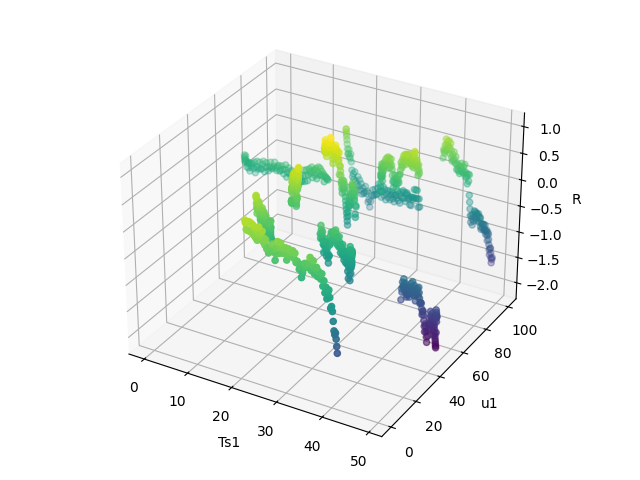

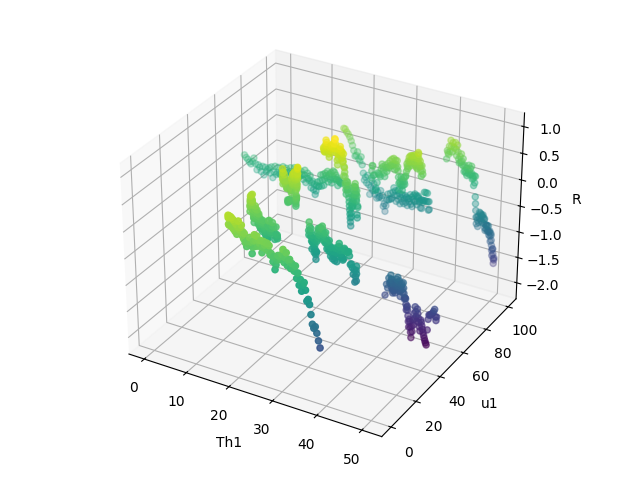

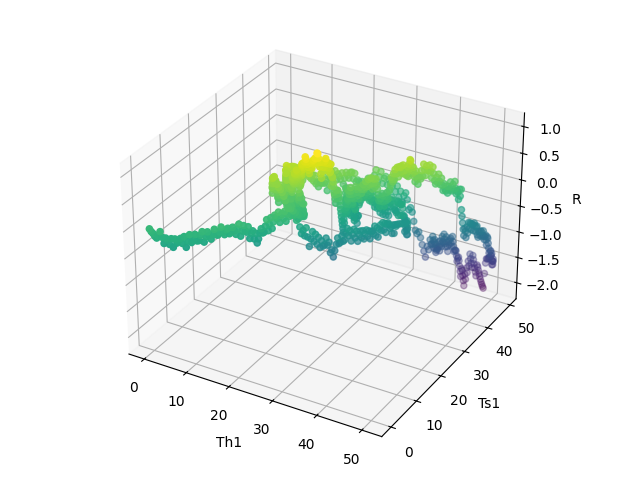

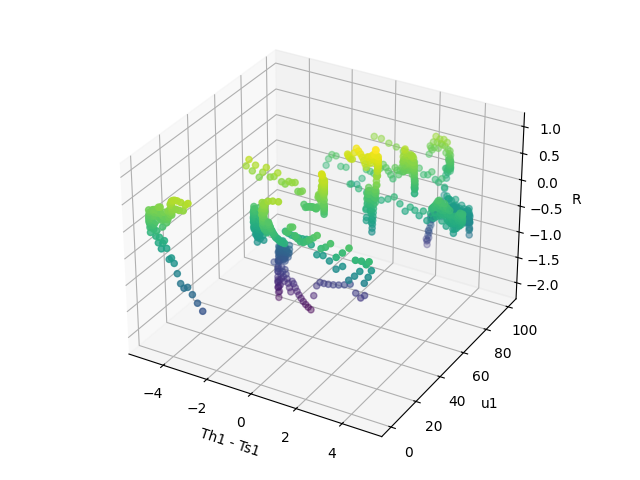

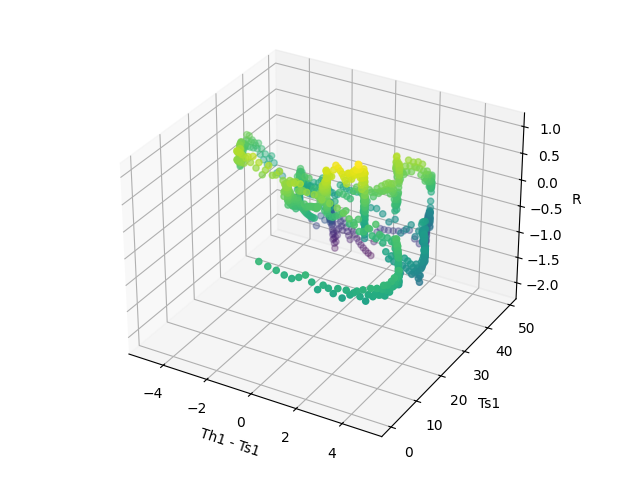

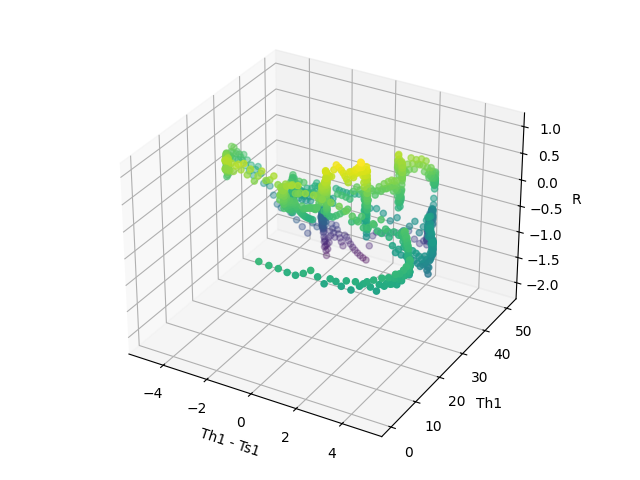

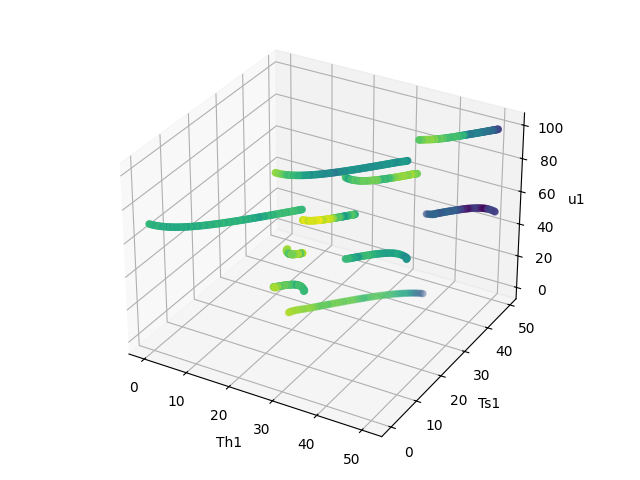

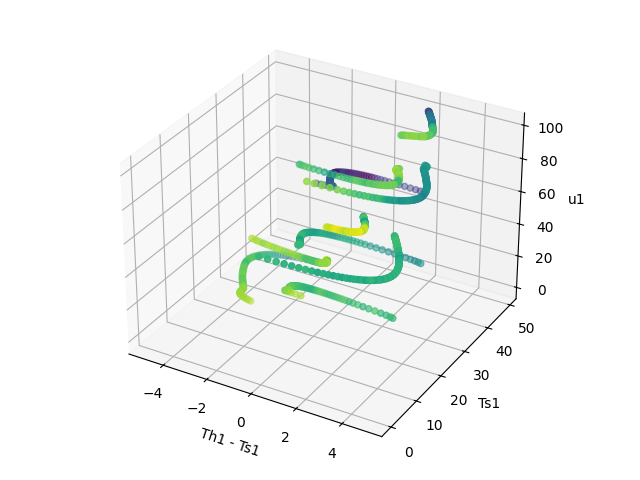

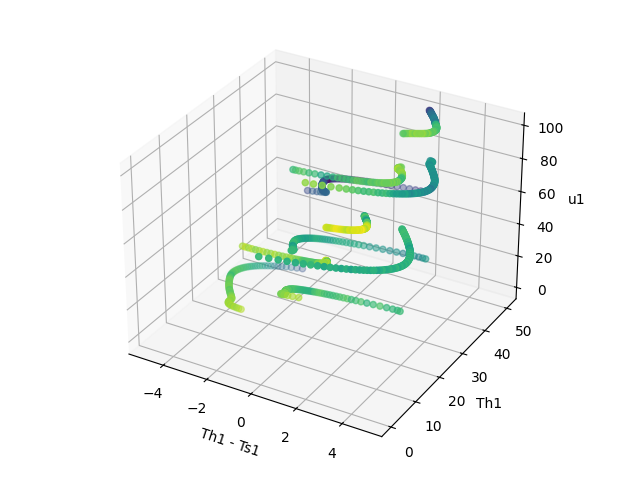

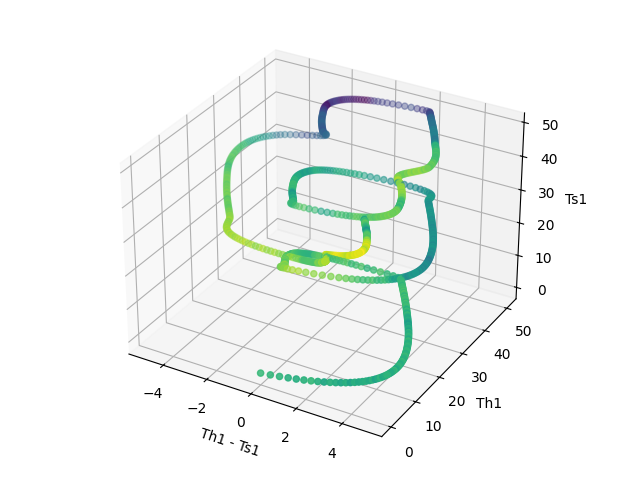

In [35]:
%matplotlib widget

for i in range(10):

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_zlabel("R")

    if i == 0:
        ax.scatter(Ts1_p, u1, R, c=R)
        ax.set_xlabel("Ts1")
        ax.set_ylabel("u1")
    elif i == 1:
        ax.scatter(Th1_p, u1, R, c=R)
        ax.set_xlabel("Th1")
        ax.set_ylabel("u1")
    elif i == 2:
        ax.scatter(Th1_p, Ts1_p, R, c=R)
        ax.set_xlabel("Th1")
        ax.set_ylabel("Ts1")
    elif i == 3:
        ax.scatter(Th1_p - Ts1_p, u1, R, c=R)
        ax.set_xlabel("Th1 - Ts1")
        ax.set_ylabel("u1")
    elif i == 4:
        ax.scatter(Th1_p - Ts1_p, Ts1_p, R, c=R)
        ax.set_xlabel("Th1 - Ts1")
        ax.set_ylabel("Ts1")
    elif i == 5:
        ax.scatter(Th1_p - Ts1_p, Th1_p, R, c=R)
        ax.set_xlabel("Th1 - Ts1")
        ax.set_ylabel("Th1")
    elif i == 6:
        ax.scatter(Th1_p, Ts1_p, u1, c=R)
        ax.set_xlabel("Th1")
        ax.set_ylabel("Ts1")
        ax.set_zlabel("u1")
    elif i == 7:
        ax.scatter(Th1_p - Ts1_p, Ts1_p, u1, c=R)
        ax.set_xlabel("Th1 - Ts1")
        ax.set_ylabel("Ts1")
        ax.set_zlabel("u1")
    elif i == 8:
        ax.scatter(Th1_p - Ts1_p, Th1_p, u1, c=R)
        ax.set_xlabel("Th1 - Ts1")
        ax.set_ylabel("Th1")
        ax.set_zlabel("u1")
    elif i == 9:
        ax.scatter(Th1_p - Ts1_p, Th1_p, Ts1_p, c=R)
        ax.set_xlabel("Th1 - Ts1")
        ax.set_ylabel("Th1")
        ax.set_zlabel("Ts1")

    fig.tight_layout()

# GP

[1, -389.23081480474184]
[2, -833.5786903683388]
[2, -1061.5429123446083]
[3, -1297.1064970878751]
[3, -1509.015869257445]
[4, -1661.0816350698751]
[4, -1703.62374178227]
[4, -1823.633021896885]
[5, -1838.4370920079796]
[5, -1915.9833421596827]
[5, -1949.1238301326475]
[6, -1949.1238301326475]
[6, -1948.62079271015]
[6, -2000.2876852383406]
[6, -2016.52469215591]
[7, -2016.135339203569]
[7, -2026.8824743758291]
[7, -2085.305779689519]
[7, -2104.5929652643495]
[8, -2104.5929652643495]
[8, -2119.4339255933783]
[8, -2129.6522489885974]
[8, -2167.629480462282]
[8, -2178.7524892052566]
[9, -2187.7308142853417]
[9, -2211.02253133236]
[9, -2213.4791878225656]
[9, -2229.9307292111225]
[9, -2236.3823586342364]
[10, -2259.7764343530926]
[10, -2263.2077338803692]
[10, -2299.8178502844894]
[10, -2355.278849149401]
[10, -2377.9926669104907]
[10, -2425.7111777528967]
[11, -2427.669026475983]
[11, -2438.0444602995003]
[11, -2440.221617024864]
[11, -2461.315864406998]
[11, -2471.5435498270226]
[11, -2

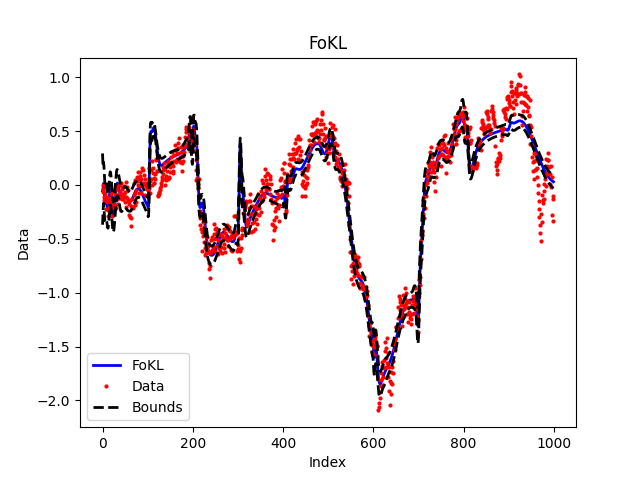

In [38]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
GP.fit([Th1_p - Ts1_p, Ts1_p], R, clean=True)
GP.save(os.path.join(dir, "models", "v13.3__betterGP.fokl"))

_ = GP.coverage3(plot=True)

[1, -390.1290332385697]
[2, -768.4762748159148]
[2, -1046.5087381141848]
[3, -1093.2665023548216]
[3, -1279.8854181884335]
[4, -1344.4864660846097]
[4, -1343.3463616736149]
[4, -1518.9647049414916]
[5, -1696.721130942889]
[5, -1694.5792795436505]
[5, -1891.9854742545567]
[6, -1895.1746246138478]
[6, -1895.5815694507637]
[6, -1909.4514485516165]
[6, -1921.4842026191277]
[7, -1924.9438588977932]
[7, -2006.141074340498]
[7, -2032.1784762744278]
[7, -2027.851249698659]
[8, -2039.345085851392]
[8, -2039.345085851392]
[8, -2041.042304499244]
[8, -2047.1326108751973]
[8, -2101.3072426513495]
[9, -2155.311935433991]
[9, -2159.211588848388]
[9, -2150.203680084531]
[9, -2154.9794675482717]
[9, -2153.1943178322113]


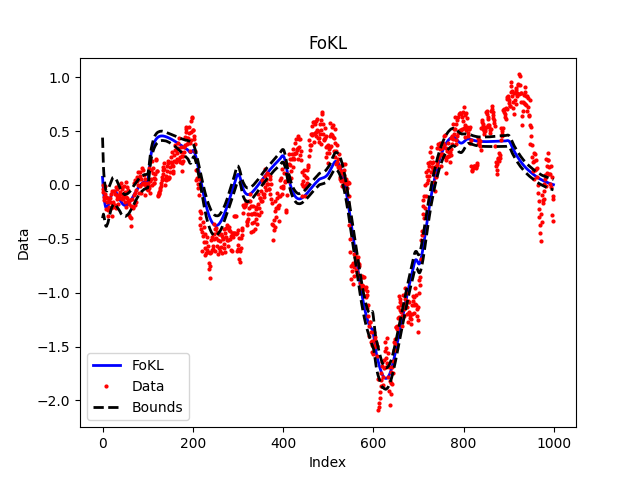

0.00030729048983897114


In [59]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
GP.fit([Th1_p, Ts1_p], R, clean=True)
_, _, rmse = GP.coverage3(plot=True)
print(rmse)

[1, -389.23081480474184]
[2, -833.5786903683388]
[2, -1061.5429123446083]
[3, -1297.1064970878751]
[3, -1509.015869257445]
[4, -1661.0816350698751]
[4, -1703.62374178227]
[4, -1823.633021896885]
[5, -1838.4370920079796]
[5, -1915.9833421596827]
[5, -1949.1238301326475]
[6, -1949.1238301326475]
[6, -1950.5455158328991]
[6, -1984.174896256548]
[6, -2018.15492083886]
[7, -2018.15492083886]
[7, -2024.874695686176]
[7, -2075.230516330188]
[7, -2107.3431562293504]
[8, -2107.3431562293504]
[8, -2116.1912327116543]
[8, -2128.2454392902255]
[8, -2153.4067184955634]
[8, -2152.1437735464565]
[9, -2157.991523429673]
[9, -2161.7622903776232]
[9, -2170.743054760054]
[9, -2217.6737197268003]
[9, -2225.0993989558533]
[10, -2242.5572820401912]
[10, -2253.107087211154]
[10, -2307.911856507403]
[10, -2322.679693620106]
[10, -2387.0287934360267]
[10, -2416.719282013123]
[11, -2432.884532623475]
[11, -2456.346383001941]
[11, -2484.015573096933]
[11, -2485.920951744088]
[11, -2486.138164695179]
[11, -2490.3

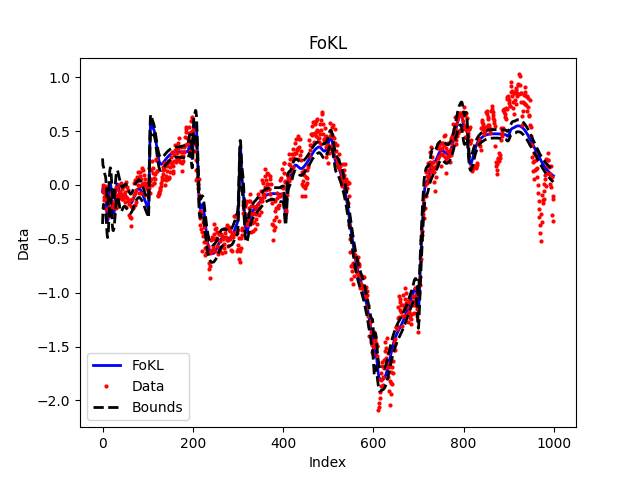

In [40]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, threshav=0.001, threshstda=0.25, threshstdb=1)
GP.fit([Th1_p - Ts1_p, Ts1_p], R, clean=True)
_ = GP.coverage3(plot=True)

[1, -389.23081480474184]
[2, -846.6211488917259]
[2, -1061.5429123446079]
[3, -1260.4736704129455]
[3, -1457.3255384223085]
[4, -1512.9582683969847]
[4, -1648.4610197345237]
[4, -1784.8921057132325]
[5, -1841.7844850409965]
[5, -1862.0270753498685]
[5, -1949.9307006143617]
[6, -1949.9307006143617]
[6, -1949.9307006143617]
[6, -1956.948986983407]
[6, -1973.331454439323]
[7, -1989.1089793523738]
[7, -1989.1089793523738]
[7, -2016.5712233362988]
[7, -2041.0876468721667]
[8, -2041.0876468721667]
[8, -2060.5503899176965]
[8, -2064.824978080638]
[8, -2078.191762579043]
[8, -2086.4996486536616]
[9, -2086.4996486536616]
[9, -2105.8170158716553]
[9, -2131.9659950547803]
[9, -2134.5294836125577]
[9, -2137.833315296066]
[10, -2137.833315296066]
[10, -2157.696028495194]
[10, -2181.114246495483]
[10, -2211.5530161721986]
[10, -2238.769585324774]
[10, -2239.7527046005434]
[11, -2239.7527046005434]
[11, -2315.5313775909817]
[11, -2315.548699898996]
[11, -2378.075197686762]
[11, -2427.046695686684]
[1

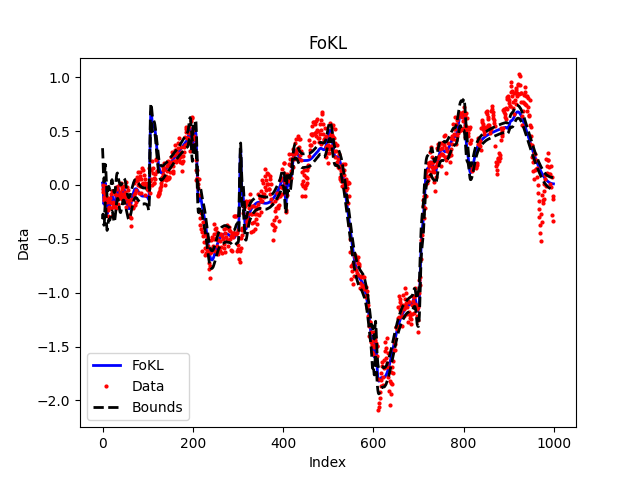

In [50]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, tolerance=25)
GP.fit([Th1_p - Ts1_p, Th1_p], R, clean=True)
_ = GP.coverage3(plot=True)

[1, -395.9199597018769]
[2, -1045.3545368632463]
[2, -1110.8560227235844]
[3, -1715.1238211666555]
[3, -1955.761999623337]
[4, -2107.3574184784543]
[4, -2173.024146621682]
[4, -2278.1164609870125]
[5, -2495.7332430105444]
[5, -2652.848101171962]
[5, -2706.94087246945]
[6, -2741.6588927066587]
[6, -2841.093612151553]
[6, -2886.3420233858387]
[6, -2900.6993332611905]
[7, -2957.113267876177]
[7, -2965.6073176842065]
[7, -3021.6976806776483]
[7, -3027.1259900206965]
[8, -3070.3633718311594]
[8, -3100.542172671271]
[8, -3013.7405857686244]
[8, -3016.0939875726517]
[8, -2678.179276113954]


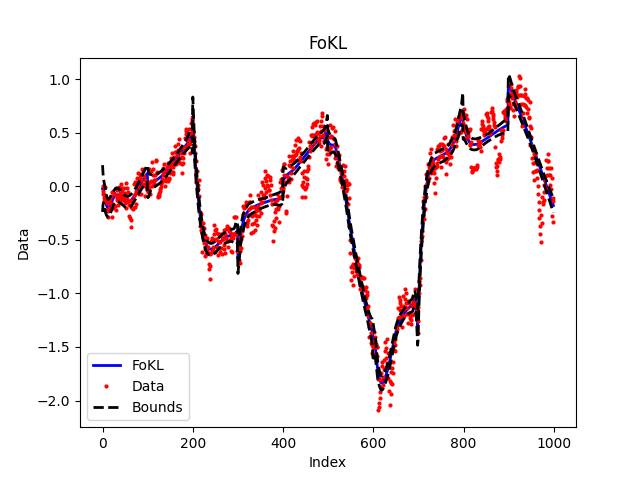

In [51]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
GP.fit([Th1_p, Ts1_p, u1], R, clean=True)
_ = GP.coverage3(plot=True)

[1, -395.9199597018769]
[2, -1045.3545368632463]
[2, -1110.8560227235844]
[3, -1158.1828498348245]
[3, -1859.8490576732056]
[3, -1987.2563645966375]
[4, -2031.0296024573022]
[4, -2132.456442803937]
[4, -2203.576628824216]
[4, -2231.3072719603783]
[5, -2429.78658174545]
[5, -2478.3665349310327]
[5, -2660.314742961487]
[5, -2754.8676747617424]
[5, -2775.239826396699]
[6, -2790.0240237502935]
[6, -2863.845169267332]
[6, -2894.193145954002]
[6, -2957.002781216075]
[6, -2934.120434978333]
[6, -2923.7290256540095]
[7, -3033.8646354357566]
[7, -3087.906625813491]
[7, -3003.1026940397915]
[7, -3053.347893770091]
[7, -3145.6019231180935]
[7, -1696.1696471184614]
[7, -1705.6399659848507]
[8, -2429.2709619821426]


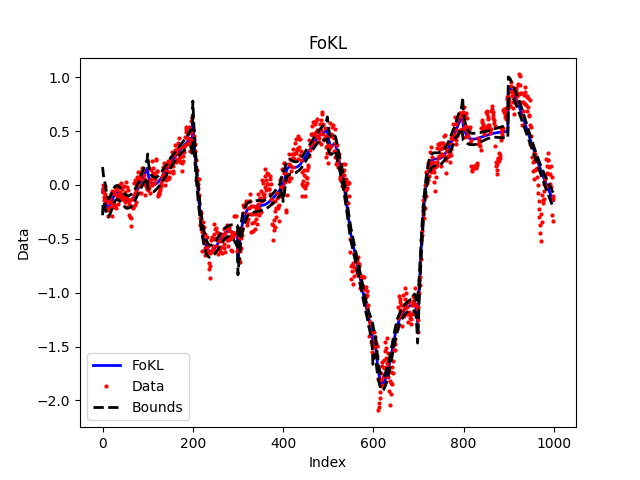

0.0001134820086634686


In [57]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)
GP.fit([Th1_p, Ts1_p, u1], R, clean=True)
_, _, rmse = GP.coverage3(plot=True)
print(rmse)

[1, -395.91995970187736]
[2, -871.825590279461]
[2, -1110.8560227235848]
[3, -1252.290530034771]
[3, -1868.3758596653297]
[3, -1987.256364596638]
[4, -2065.254814811985]
[4, -2073.785659931724]
[4, -2131.8764622846556]
[4, -2288.235193788744]
[5, -2415.1734797452114]
[5, -2476.4628922119655]
[5, -2678.13078443171]
[5, -2783.260724399983]
[5, -2792.7718625144453]
[6, -2794.0326281450284]
[6, -2884.5568045222417]
[6, -2894.9522061973084]
[6, -2969.8254903248726]
[6, -2989.389714242602]
[6, -2994.5849534705317]
[7, -3015.7669550474975]
[7, -3032.5044999282673]
[7, -3136.762786651422]
[7, -3146.183230000386]
[7, -3195.0782326360877]
[7, -3201.417487950167]
[7, -3204.37163075183]
[8, -3237.495048299633]
[8, -3239.66988119127]
[8, -3237.2730841281336]
[8, -3327.0473226469385]
[8, -3313.7183396182645]
[8, -3379.1686813578244]
[8, -3390.699585225183]
[8, -3378.77055113647]
[9, -3378.77055113647]
[9, -3424.8564126373794]
[9, -3406.26814702338]
[9, -3458.5501960375686]
[9, -3476.7453854499518]
[

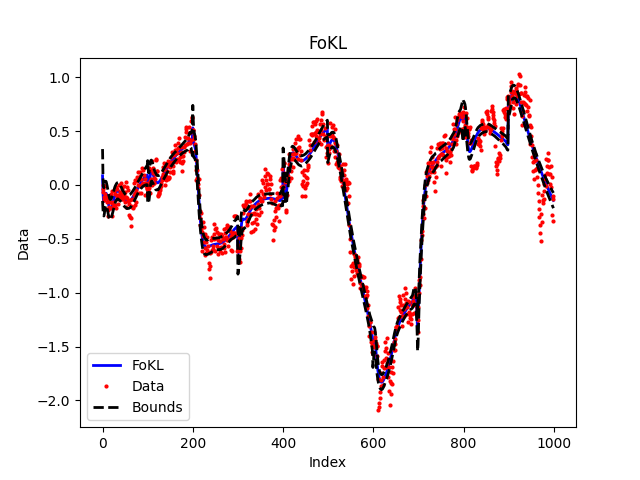

9.905940186779219e-05


In [58]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)
GP.fit([Th1_p - Ts1_p, Ts1_p, u1], R, clean=True)
_, _, rmse = GP.coverage3(plot=True)
print(rmse)

[1, -395.91995970187736]
[2, -871.825590279461]
[2, -1110.8560227235848]
[3, -1868.954164877288]
[3, -1981.0269872136018]
[4, -2017.19374740258]
[4, -2074.10153899305]
[4, -2214.0327486889096]
[5, -2506.8601047223146]
[5, -2586.490737328779]
[5, -2624.698119646767]
[6, -2741.5608623266544]
[6, -2863.907361929559]
[6, -2909.3662247368284]
[6, -2917.7049751794366]
[7, -2940.0473222277296]
[7, -2960.7340628414204]
[7, -3017.607576701973]
[7, -3068.850025770001]
[8, -3109.131135632034]
[8, -3126.9415832564164]
[8, -3175.6232381434347]
[8, -3207.142126827197]
[8, -3204.291514484563]
[9, -3221.9179395103183]
[9, -3239.519522018686]
[9, -3289.174379757441]
[9, -3327.0542072854287]
[9, -3321.729653157873]
[10, -3366.7681191536603]
[10, -3436.268989199747]
[10, -3425.9623493971776]
[10, -3491.009111990891]
[10, -3470.4053999466423]
[10, -3485.14003578716]
[11, -3516.502513671212]
[11, -3528.8202513996875]
[11, -3525.832995594028]
[11, -3526.8487798437836]
[11, -3315.4414516867982]


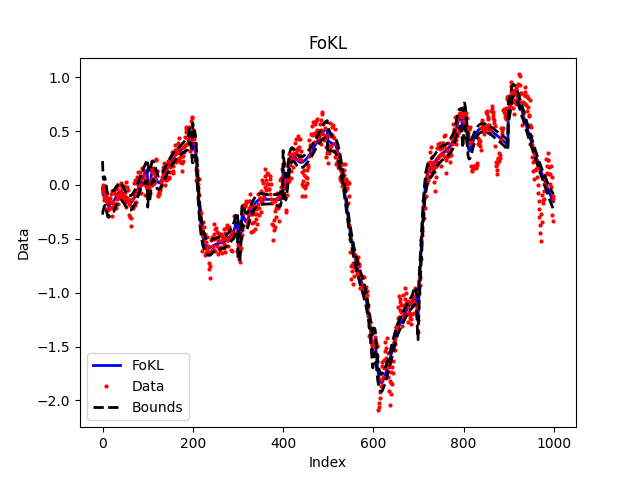

In [54]:
GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
GP.fit([Th1_p - Ts1_p, Ts1_p, u1], R, clean=True)